# RAG System Overview

## 🔍 Components

### **Vector Database (Chroma)**
- Efficient storage and similarity search of embeddings.
- Enables retrieval of semantically relevant document chunks.

### **Sentence Transformers**
- Generates high-quality text embeddings using models like `all-MiniLM-L6-v2`.
- Converts text into vector representations for semantic analysis.

### **LangChain**
- Manages text splitting with `RecursiveCharacterTextSplitter` to create context-aware chunks.

### **LiteLLM**
- Interfaces with the Gemini model to generate responses using retrieved context.
- Integrated with **OpikLogger** for tracking LLM interactions.

### **PyPDF2**
- Extracts text from PDFs to build the knowledge base.

### **Opik**
- A monitoring and evaluation platform for LLM applications.
- Logs interactions, computes metrics (e.g., hallucination, context recall/precision), and evaluates RAG system performance.

---

## ⚙️ Methods and Steps

### **Step 1: Extract Text from PDFs**
- Process all PDFs in a folder using PyPDF2 and combine extracted text.

### **Step 2: Split Text into Chunks**
- Use LangChain’s `RecursiveCharacterTextSplitter` to create overlapping, semantically meaningful chunks.

### **Step 3: Generate Embeddings**
- Convert chunks into vectors using Sentence Transformers.

### **Step 4: Build the Knowledge Base**
- Store embeddings and chunks in Chroma for efficient retrieval.

### **Step 5: Perform Semantic Search**
- Convert user queries into embeddings and retrieve top-k relevant chunks from Chroma.

### **Step 6: Generate Responses with Gemini**
- Pass retrieved context to Gemini via LiteLLM to generate answers.
- `OpikLogger` tracks API calls, spans, and metadata for monitoring.

### **Step 7: Evaluate RAG Performance with Opik**
- Define evaluation metrics:
  - **Hallucination**: Detects fabricated or irrelevant information in responses.
  - **Context Recall**: Measures retrieval of all relevant chunks.
  - **Context Precision**: Assesses relevance of retrieved chunks.
- Run experiments on a QA dataset to score responses and log results.

---

## 📊 Workflow Overview

### **Input**
- Folder of PDF documents and evaluation dataset (QA pairs).

### **Processing**
- Extract text, split into chunks, generate embeddings, and build Chroma knowledge base.

### **Query Handling**
- Retrieve context from Chroma and generate answers with Gemini.

### **Evaluation & Monitoring**
- Opik evaluates response quality, computes metrics, and logs interactions.
- Tracks model performance and retrieval effectiveness in real time.

---

## ✅ Why This Approach?

- **Contextual Understanding**: Semantic search ensures relevance beyond keyword matching.
- **Efficient Retrieval**: Chroma enables scalable similarity searches.
- **High-Quality Responses**: Gemini generates accurate, context-aware answers.
- **Robust Evaluation**: Opik provides actionable insights into hallucination rates, context relevance, and system reliability.
- **Continuous Improvement**: Logging and monitoring allow iterative refinement of the RAG pipeline.

> This notebook emphasizes **end-to-end transparency** through Opik’s evaluation framework, ensuring both the retrieval and generation processes meet high standards of accuracy and relevance.

---
Let’s get started! You can see the full workflow in the diagram below.


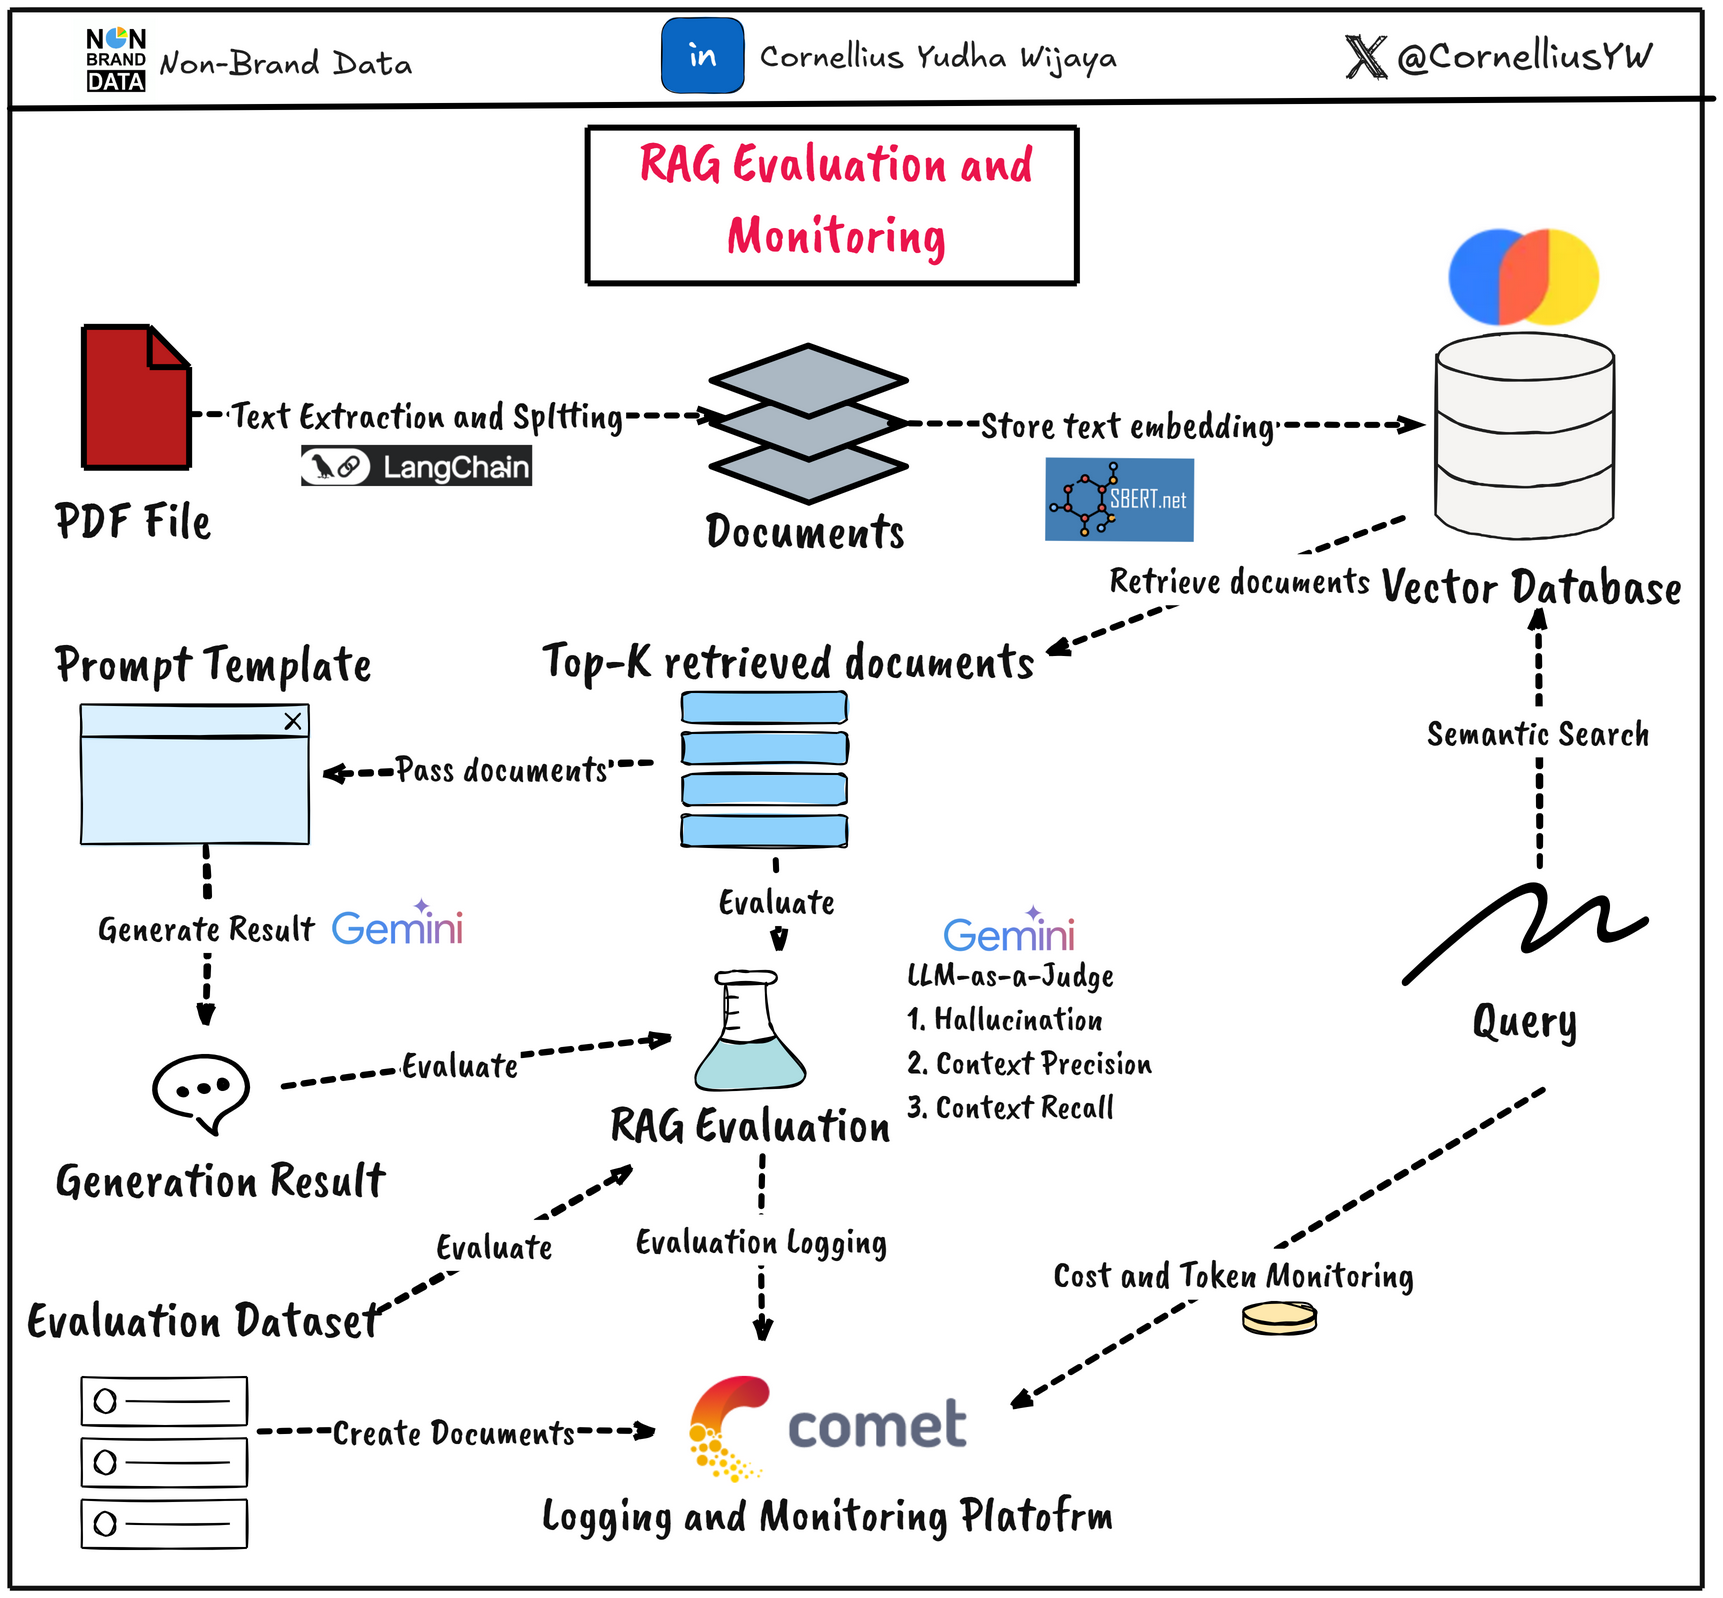

## Library Installation

Start by installing the library used in this Notebook

In [ ]:
!pip install -q chromadb pypdf2 sentence-transformers litellm langchain opik

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.9/537.9 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 11.7 MB/s et

## Import the Libraries and set the environment variables

In [ ]:
import os

import pandas as pd

import PyPDF2

from sentence_transformers import SentenceTransformer

import chromadb
from chromadb.config import Settings

import litellm
from litellm import completion
from litellm.integrations.opik.opik import OpikLogger

from langchain.text_splitter import RecursiveCharacterTextSplitter

from opik import track, Opik
from opik.opik_context import get_current_span_data
from opik.evaluation import evaluate, models
from opik.evaluation.metrics import Hallucination, ContextRecall, ContextPrecision


## Set environment variables. Uncomment this if you want to set them directly.
# os.environ["HUGGINGFACE_TOKEN"] = "YOUR_HF_TOKEN"
# os.environ["GEMINI_API_KEY"] = "YOUR_GEMINI_TOKEN"
# os.environ['LITELLM_LOG'] = 'DEBUG'

# os.environ["OPIK_API_KEY"] = "YOUR_API_OPIK_TOKEN"
# os.environ["OPIK_WORKSPACE"] = "YOUR_WORKSPACE_NAME"
# os.environ["OPIK_PROJECT_NAME"] = "YOUR_PROJECT_NAME"

# GEMINI_API_KEY = "YOUR_GEMINI_TOKEN"

## Extract Text from folder containing PDF files

In [ ]:
def extract_text_from_pdfs(folder_path):
    all_text = ""
    for filename in os.listdir(folder_path):
        if filename.endswith(".pdf"):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'rb') as file:
                reader = PyPDF2.PdfReader(file)
                for page in reader.pages:
                    all_text += page.extract_text()
    return all_text

pdf_folder = "dataset"
all_text = extract_text_from_pdfs(pdf_folder)

## Text Splitter

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,  # Size of each chunk
    chunk_overlap=50,  # Overlap between chunks to maintain context
    separators=["\n\n", "\n", " ", ""]  # Splitting hierarchy
)

chunks = text_splitter.split_text(all_text)

## Set up the Knowledge Base with ChromaDB and Generate Embeddings with sentence-transformers

In [ ]:
# Initialize a persistent ChromaDB client
client = chromadb.PersistentClient(path="chroma_db")

# Load the SentenceTransformer model for text embeddings
text_embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Delete existing collection (if needed)
try:
    client.delete_collection(name="knowledge_base")
    print("Deleted existing collection: knowledge_base")
except Exception as e:
    print(f"Collection does not exist or could not be deleted: {e}")

# Create a new collection for text embeddings
collection = client.create_collection(name="knowledge_base")

# Add text chunks to the collection
for i, chunk in enumerate(chunks):
    # Generate embeddings for the chunk
    embedding = text_embedding_model.encode(chunk)

    # Add to the collection with metadata
    collection.add(
        ids=[f"chunk_{i}"],  # Unique ID for each chunk
        embeddings=[embedding.tolist()],  # Embedding vector
        metadatas=[{"source": "pdf", "chunk_id": i}],  # Metadata
        documents=[chunk]  # Original text
    )

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Collection does not exist or could not be deleted: Collection [knowledge_base] does not exists


## Perform Semantic Search with ChromaDB and Embedding Model

In [ ]:
def semantic_search(query, top_k=2):
    # Generate embedding for the query
    query_embedding = text_embedding_model.encode(query)

    # Query the collection
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k
    )
    return results

# Example query
query = "What is the insurance for car?"
results = semantic_search(query)

# Display results
for i, result in enumerate(results['documents'][0]):
    print(f"Result {i+1}: {result}\n")

Result 1: insurance) 
FINANCIAL RESPONSIBILITY LAW
A state law requiring that all automobile 
drivers show proof that they can pay dam-
ages up to a minimum amount if involved 
in an auto accident. Varies from state to 
state but can be met by carrying a mini-
mum amount of auto liability insurance. 
(See Compulsory auto insurance)
FINITE RISK REINSURANCE
Contract under which the ultimate li-
ability of the reinsurer is capped and on 
which anticipated investment income is

Result 2: policyholder’s car from a collision. 
5. Comprehensive, for damage to the poli-
cyholder’s car not involving a collision 
with another car (including damage 
from fire, explosions, earthquakes, floods, and riots), and theft. 6. Uninsured motorists coverage, for costs 
resulting from an accident involving a hit-and-run driver or a driver who does not have insurance. 
AUTO INSURANCE PREMIUM
The price an insurance company charges 
for coverage, based on the frequency and



## Generate Repsonse Based on Semantic Search and Monitor the Call with Opik

In [ ]:
# Set up LiteLLM with Gemini and Monitor the result with Opik
opik_logger = OpikLogger()
litellm.callbacks = [opik_logger]

model_name = "gemini/gemini-2.0-flash-lite"
query = "What is the insurance for car?"

@track
def generate_response(query: str, context: str):
    # build the prompt
    prompt = f"Query: {query}\nContext: {context}\nAnswer:"

    # call Gemini via LiteLLM
    response = completion(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        api_key=GEMINI_API_KEY,
        metadata = {
            "opik": {
                "current_span_data": get_current_span_data(),
                "tags": ["insurance-rag-test"],
            }
            }
    )

    # extract the generated text
    generated = response["choices"][0]["message"]["content"]
    return generated

# perform semantic search
search_results = semantic_search(query)
context = "\n".join(search_results["documents"][0])

# generate the completion
response = generate_response(query, context)

print("Generated Response:\n", response)

Generated Response:
 The context provides information about different types of auto insurance:

*   **Minimum auto liability insurance:** This meets the requirements of Financial Responsibility Laws and covers damages if you are at fault in an accident.
*   **Collision insurance:** Covers damage to your car from a collision.
*   **Comprehensive insurance:** Covers damage to your car not involving a collision (e.g., fire, theft).
*   **Uninsured motorists coverage:** Covers costs if you're in an accident with an uninsured driver.

Additionally, it mentions the **auto insurance premium**, which is the price you pay for the coverage.



## Prepare RAG Evaluation Dataset for Experiment in Opik

In [ ]:
insurance_qa = pd.read_csv('/content/dataset/96_sample_insurance_qa.csv')

examples = [
    {
        "input": q, "context": c, "expected_output": a
    }
    for q, c, a in zip(
        insurance_qa["question"],
        insurance_qa["context"],
        insurance_qa["answer"]
    )
]

client = Opik()
dataset = client.get_or_create_dataset(name="Insurance-96-QA-Dataset")

dataset.insert(examples)

## Prepare for RAG Evaluation Experiment with Opik.

In this experiment, we will use the following metrics based on LLM-as-a-Judge:

1. Hallucination: Check if the LLM response contains any hallucinated information.
2. Context Precision: Measures how many of the retrieved chunks were actually relevant to the query.
3. Context Recall: Measures how many of the relevant chunks were successfully retrieved.

In [ ]:
def evaluation_task(x: dict) -> dict:
    answer = generate_response(x["input"], x["context"])
    return {
        "input": x["input"],
        "output": answer,
        "context": x["context"],
        "expected_output": x["expected_output"]
    }


experiment_config = {
    "model_id": "gemini/gemini-2.0-flash-lite",
    "embedding_model_id": "all-MiniLM-L6-v2"
}

model = models.LiteLLMChatModel(
    model_name="gemini/gemini-2.0-flash-lite"
)

scoring_metrics = [
    Hallucination(model=model),
    ContextRecall(model=model),
    ContextPrecision(model=model)
]

evaluate(
    dataset=dataset,
    task=evaluation_task,
    scoring_metrics=scoring_metrics,
    experiment_config=experiment_config,
    task_threads=1,
    nb_samples=9
)

Evaluation:   0%|          | 0/9 [00:00<?, ?it/s]

╭─ Insurance-96-QA-Dataset (9 samples) ──╮
│                                        │
│ Total time:        00:01:29            │
│ Number of samples: 9                   │
│                                        │
│ hallucination_metric: 0.0000 (avg)     │
│ context_recall_metric: 0.8778 (avg)    │
│ context_precision_metric: 0.8222 (avg) │
│                                        │
╰────────────────────────────────────────╯

Uploading results to Opik ...

View the results ]8;id=500432;https://www.comet.com/opik/api/v1/session/redirect/experiments/?experiment_id=0196cdbf-4eac-7996-b15c-de116f97eb18&dataset_id=0196ca6a-4732-78fa-a1de-233396f4a3ec&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==\in your Opik dashboard]8;;\.

EvaluationResult(experiment_id='0196cdbf-4eac-7996-b15c-de116f97eb18', experiment_name='double_rabbit_3817', test_results=[TestResult(test_case=TestCase(trace_id='0196cdbf-50bf-77a4-bf00-b73798c102b3', dataset_item_id='0196ca6f-51f9-78c7-a68d-9ea7fd828505', scoring_inputs={'input': 'What are the five main types of coverage typically included in a car insurance policy?', 'expected_output': 'The five main types of coverage are bodily injury liability, medical payments/PIP, property damage liability, collision, and comprehensive.', 'context': "1.  Bodily injury liability, for injuries the policyholder causes to someone else.\n2.  Medical payments or Personal Injury Protection (PIP) for treatment of injuries to the driver and passengers of the policyholder's car.\n3.  Property damage liability, for damage the policyholder causes to someone else's property.\n4.  Collision, for damage to the policyholder's car from a collision.\n5.  Comprehensive, for damage to the policyholder's car not inv